# Open Food Facts 过敏原预测：TF-IDF + SVM、mBERT 与 XLM-R 比较

本 notebook 在相同数据切分和标签处理下，比较经典 TF-IDF + Linear SVM baseline 与两种多语 Transformer：

| 模型 | 配置 |
|---|---|
| mBERT | `bert-base-multilingual-cased` |
| XLM-R | `xlm-roberta-base` |
| TF-IDF + Linear SVM | 字符 3–5 gram，One-vs-Rest |

任务是根据配料表进行 14 类欧盟常见过敏原的多标签预测。为避免数据泄漏，按产品 `code` 分组切分；测试集只用于最终比较。


## Global threshold tuning experiment
All models use seed 42. Transformer decisions use probability ≥ 0.50; LinearSVC uses decision score ≥ 0.0. No threshold is selected from validation data. Final metrics use the labels returned alongside predictions to prevent prediction–label order mismatches.


In [1]:
# %pip install -U transformers datasets accelerate evaluate sentencepiece pyarrow scikit-learn

import html
import json
import random
import re
import unicodedata
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.svm import LinearSVC
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

DATA_SEED = 42  # data splitting seed
SEEDS = [42]  # # Model seed
random.seed(DATA_SEED)
np.random.seed(DATA_SEED)
torch.manual_seed(DATA_SEED)

FILE_PATH = Path("./data/food.parquet")
TARGET_LANGUAGES = ["en", "fr", "de", "es", "nl", "it", "pt", "pl"]
MAX_RECORDS_PER_LANGUAGE = 8_000  # max records per language is 8000
PARQUET_BATCH_SIZE = 100_000  # batch reading parquet file

# include all 14 dimensions = 0 samples
INCLUDE_NO_ALLERGEN = True

# Limit the number of all-zero samples relative to the number of positive-labeled samples in each language to avoid overwhelming positive samples with a large number of weak negatives.
MAX_NO_ALLERGEN_TO_POSITIVE_RATIO = 1.0

# 70% train、10% validation、20% test
VALIDATION_SIZE = 0.10
TEST_SIZE = 0.20

# hyperparameters
MAX_LENGTH = 256
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16
EPOCHS = 6
LEARNING_RATE = 2e-5


ENABLE_TF32 = True 
USE_BF16_IF_AVAILABLE = True  
DATALOADER_NUM_WORKERS = 2  
GROUP_BY_LENGTH = False  

# Threshold
DEFAULT_PROB_THRESHOLD = 0.50
DEFAULT_SVM_THRESHOLD = 0.0
GLOBAL_THRESHOLD_OBJECTIVE = "macro"  # only use validation；test not involved。
PROB_THRESHOLD_GRID = np.linspace(0.05, 0.95, 181)

MODEL_SPECS = {
    "mBERT": "bert-base-multilingual-cased",
    "XLM-R": "xlm-roberta-base",
}
OUTPUT_ROOT = Path("./models/mbert_xlmr_allergen_comparison")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print("GPU available:", torch.cuda.is_available())


E:\anaconda\envs\ai-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU available: True


## 1. 读取数据与清理标签


### 内存安全的数据读取

原始 Parquet 约有459万行。该版本使用 `iter_batches` 分批读取，并对每种语言的正样本和 no-allergen 样本执行固定随机种子的 reservoir sampling。任何时刻都只保留最终实验可能用到的候选行，避免在完整 DataFrame 上增加 object 列或执行 `.copy()`。最终的每语言上限、no-allergen 比例限制、标签编码和后续切分逻辑保持不变。


In [2]:

if not FILE_PATH.exists():
    raise FileNotFoundError(f"cannot find file: {FILE_PATH.resolve()}")

required_columns = ["code", "lang", "ingredients_text", "allergens_tags"]
try:
    import pyarrow.parquet as pq
except ImportError as exc:
    raise ImportError("Install pyarrow first: pip install pyarrow") from exc

available_columns = pq.read_schema(FILE_PATH).names
missing = [column for column in required_columns if column not in available_columns]
if missing:
    raise KeyError(f"Missing necessary column：{missing}")

parquet_file = pq.ParquetFile(FILE_PATH)
print(f"Parquet total records：{parquet_file.metadata.num_rows:,}")
print(f"each batch is processed in a streaming manner with a maximum of  {PARQUET_BATCH_SIZE:,} rows, instead of loading all records at once.")


Parquet total records：4,591,671
each batch is processed in a streaming manner with a maximum of  100,000 rows, instead of loading all records at once.


In [3]:
CANONICAL_ALLERGENS = [
    "en:gluten", "en:crustaceans", "en:eggs", "en:fish", "en:peanuts",
    "en:soybeans", "en:milk", "en:nuts", "en:celery", "en:mustard",
    "en:sesame-seeds", "en:sulphur-dioxide-and-sulphites", "en:lupin", "en:molluscs",
]

# keywords matching
KEYWORD_RULES = {
    "en:milk": ["milk", "lait", "milch", "leche", "latte", "melk", "mleko", "lactose", "yaourt", "fromage"],
    "en:gluten": ["gluten", "ble", "wheat", "weizen", "trigo", "farine", "flour", "avoine", "hafer", "avena", "oat", "orge", "gerste", "barley", "seigle", "roggen", "rye", "dinkel", "spelt"],
    "en:eggs": ["egg", "oeuf", "eier", "huevo", "uovo", "eipulver"],
    "en:soybeans": ["soy", "soja", "sojabohnen", "sojalecithin", "sojaprotein"],
    "en:nuts": ["noisette", "hazelnut", "amande", "almond", "pistache", "pistachio", "cashew", "pecan", "walnut", "noix", "nuss", "nut "],
    "en:mustard": ["moutarde", "senf", "mustard", "mostaza"],
    "en:celery": ["sellerie", "celery", "apio", "celeri"],
    "en:sulphur-dioxide-and-sulphites": ["sulfite", "sulphite", "sulfit", "metabisulf", "disulfite", "so2"],
    "en:fish": ["poisson", "fisch", "pescado", "pesce"],
    "en:crustaceans": ["crustace", "krebstiere", "crustaceo"],
    "en:molluscs": ["mollusque", "weichtiere", "molusco"],
    "en:lupin": ["lupin", "lupine", "lupino"],
    "en:sesame-seeds": ["sesame", "sesamo", "sesam"],
    "en:peanuts": ["peanut", "arachide", "erdnuss", "cacahuete"],
}
NEGATIVE_PATTERNS = ["none", "ausencia", "non renseigne", "non-renseigne", "neant", "aucun allergene", "keine allergene"]


def normalize_tag(tag):
    if tag in CANONICAL_ALLERGENS:
        return tag
    text = unicodedata.normalize("NFKD", str(tag).split(":", 1)[-1]).lower()
    text = "".join(c for c in text if not unicodedata.combining(c)).replace("-", " ").replace("_", " ")
    if any(pattern in text for pattern in NEGATIVE_PATTERNS):
        return "__NEGATIVE__"
    for label, keywords in KEYWORD_RULES.items():
        if any(keyword in text for keyword in keywords):
            return label
    return None


unmatched_tag_counts = Counter()


def clean_tags(value):
    """Compatible with OFF for lists, numpy.ndarrays, single strings, and missing values."""
    if value is None:
        tags = []
    elif isinstance(value, float) and pd.isna(value):
        tags = []
    elif isinstance(value, str):
        tags = [value]
    elif isinstance(value, (list, tuple, set, np.ndarray)):
        tags = list(value)
    else:
        tags = []

    labels = set()
    for tag in tags:
        mapped = normalize_tag(tag)
        if mapped in CANONICAL_ALLERGENS:
            labels.add(mapped)
        elif mapped is None:
            unmatched_tag_counts[str(tag)] += 1
    return sorted(labels)



In [4]:
def clean_ingredient_text(text):
    if not isinstance(text, str):
        return None
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = text.replace("_", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text or None

# Extract text from ingredients_text, Compatible  for  str、dict、list、tuple and ndarray
def extract_main_text(value):
    
    if value is None:
        return None
    if isinstance(value, str):
        return clean_ingredient_text(value)
    if isinstance(value, dict):
        return clean_ingredient_text(value.get("text"))
    if isinstance(value, (list, tuple, np.ndarray)):
        entries = [item for item in value if isinstance(item, dict) and item.get("text")]
        if not entries:
            return None
        main = next((item for item in entries if item.get("lang") == "main"), None)
        return clean_ingredient_text((main or entries[0]).get("text"))
    return None

#   allergens_tags contains at least one non-empty tag.
def has_raw_tags(value):
  
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return False
    if isinstance(value, str):
        return bool(value.strip())
    if isinstance(value, (list, tuple, set, np.ndarray)):
        return any(str(tag).strip() for tag in value if tag is not None)
    return False

# Random priority reservoir: Always retains only the maximum limit of candidate rows in memory.
def retain_smallest_keys(existing, incoming, limit):
    
    if incoming.empty:
        return existing
    combined = incoming if existing is None else pd.concat([existing, incoming], ignore_index=True)
    if limit is not None and len(combined) > limit:
        combined = combined.nsmallest(limit, "_sample_key")
    return combined.reset_index(drop=True)


# For each language, positive samples and all-zero candidates are retained separately. The upper limit is slightly higher than the final requirement so that proportional sampling can be performed later.
candidate_limit = MAX_RECORDS_PER_LANGUAGE
positive_pools = {language: None for language in TARGET_LANGUAGES}
zero_pools = {language: None for language in TARGET_LANGUAGES}
rng = np.random.default_rng(DATA_SEED)
rows_scanned = 0

for batch_number, record_batch in enumerate(
    parquet_file.iter_batches(batch_size=PARQUET_BATCH_SIZE, columns=required_columns), start=1
):
    batch_df = record_batch.to_pandas()
    rows_scanned += len(batch_df)

    # filter languages ​​in small batches; do not perform deep copies of DataFrames with millions of rows.
    batch_df = batch_df.loc[batch_df["lang"].isin(TARGET_LANGUAGES)]
    if batch_df.empty:
        continue

    batch_df["text"] = batch_df["ingredients_text"].apply(extract_main_text)
    batch_df = batch_df.loc[batch_df["text"].notna() & batch_df["text"].str.len().gt(0)]
    if batch_df.empty:
        continue

    batch_df["has_raw_allergen_tag"] = batch_df["allergens_tags"].apply(has_raw_tags)
    batch_df["allergens_clean"] = batch_df["allergens_tags"].apply(clean_tags)
    batch_df["is_no_allergen"] = ~batch_df["has_raw_allergen_tag"]
    positive_mask = batch_df["allergens_clean"].map(len).gt(0)
    eligible_mask = positive_mask | (INCLUDE_NO_ALLERGEN & batch_df["is_no_allergen"])
    batch_df = batch_df.loc[eligible_mask, [
        "code", "lang", "text", "allergens_clean",
        "has_raw_allergen_tag", "is_no_allergen",
    ]]
    if batch_df.empty:
        continue

    # Independent random keys make retaining the minimum key across batches equivalent to a fixed-size random reservoir.
    batch_df["_sample_key"] = rng.random(len(batch_df))
    for language, language_df in batch_df.groupby("lang", sort=False):
        positive_part = language_df.loc[~language_df["is_no_allergen"]]
        zero_part = language_df.loc[language_df["is_no_allergen"]]
        positive_pools[language] = retain_smallest_keys(
            positive_pools[language], positive_part, candidate_limit
        )
        if INCLUDE_NO_ALLERGEN:
            zero_pools[language] = retain_smallest_keys(
                zero_pools[language], zero_part, candidate_limit
            )

    del batch_df
    if batch_number % 10 == 0:
        print(f"Scanned {rows_scanned:,} rows...")


sampled_parts = []
for language in TARGET_LANGUAGES:
    positives = positive_pools[language]
    negatives = zero_pools[language]
    positives = positives if positives is not None else pd.DataFrame()
    negatives = negatives if negatives is not None else pd.DataFrame()

    if INCLUDE_NO_ALLERGEN and MAX_NO_ALLERGEN_TO_POSITIVE_RATIO is not None:
        max_negatives = int(len(positives) * MAX_NO_ALLERGEN_TO_POSITIVE_RATIO)
        if len(negatives) > max_negatives:
            negatives = negatives.nsmallest(max_negatives, "_sample_key")

    language_sample = pd.concat([positives, negatives], ignore_index=True)
    if MAX_RECORDS_PER_LANGUAGE is not None and len(language_sample) > MAX_RECORDS_PER_LANGUAGE:
        # Maintain the current positive/all-zero ratio within the final total limit.
        fraction = MAX_RECORDS_PER_LANGUAGE / len(language_sample)
        selected = []
        for _, part in language_sample.groupby("is_no_allergen", sort=False):
            n = max(1, min(len(part), int(round(len(part) * fraction))))
            selected.append(part.nsmallest(n, "_sample_key"))
        language_sample = pd.concat(selected, ignore_index=True)
        if len(language_sample) > MAX_RECORDS_PER_LANGUAGE:
            language_sample = language_sample.nsmallest(MAX_RECORDS_PER_LANGUAGE, "_sample_key")
    sampled_parts.append(language_sample)

df = pd.concat(sampled_parts, ignore_index=True).drop(columns="_sample_key")
del positive_pools, zero_pools, sampled_parts

mlb = MultiLabelBinarizer(classes=CANONICAL_ALLERGENS)
Y = mlb.fit_transform(df["allergens_clean"])
if len(df) != len(Y):
    raise RuntimeError("The number of rows in df is inconsistent with the number of rows in the label matrix Y.")

zero_mask = Y.sum(axis=1) == 0
dataset_stats = pd.Series({
    "scanned_parquet_rows": rows_scanned,
    "all_samples": len(Y),
    "positive_label_samples": int((~zero_mask).sum()),
    "no_allergen_zero_vector_samples": int(zero_mask.sum()),
    "no_allergen_ratio": float(zero_mask.mean()),
})
print(f"Number of records to be modeled:{len(df):,}; Label matrix:{Y.shape}")
print("Number of unmapped tag types:", len(unmatched_tag_counts))
print("Most common unmapped tags:", unmatched_tag_counts.most_common(20))
display(dataset_stats.to_frame("value"))
display(pd.Series(Y.sum(axis=0), index=mlb.classes_).sort_values(ascending=False))

Scanned 1,000,000 rows...
Scanned 2,000,000 rows...
Scanned 3,000,000 rows...
Scanned 4,000,000 rows...
Number of records to be modeled:64,000; Label matrix:(64000, 14)
Number of unmapped tag types: 4687
Most common unmapped tags: [('en:pork', 12621), ('en:gelatin', 10783), ('en:beef', 10362), ('en:apple', 8674), ('en:orange', 6044), ('en:chicken', 4150), ('en:banana', 2459), ('en:kiwi', 1253), ('en:peach', 818), ('en:coconut', 285), ('fr:et-produits-a-base-de-ces-cereales', 125), ('fr:non', 119), ('es:tartrazina', 109), ('fr:ferments', 98), ('pl:sojowego', 89), ('pl:laktoza', 67), ('fr:chapelure', 53), ('fr:ingredients', 53), ('fr:citron', 49), ('fr:constituants-analytiques', 45)]


,value
scanned_parquet_rows,4.591671e+06
all_samples,6.400000e+04
positive_label_samples,3.399300e+04
no_allergen_zero_vector_samples,3.000700e+04
no_allergen_ratio,4.688594e-01


en:milk                             17626
en:gluten                           14903
en:soybeans                          8879
en:eggs                              5621
en:nuts                              4368
en:mustard                           2307
en:fish                              1920
en:celery                            1800
en:peanuts                           1781
en:sesame-seeds                      1501
en:sulphur-dioxide-and-sulphites     1178
en:crustaceans                        415
en:molluscs                           291
en:lupin                              244
dtype: int64

## Split to train_set / val_set / test_set

Split the unique product code, then put all the records corresponding to the product into the same set, thus avoiding the same product entering multiple datasets. The final target ratio is 70% training set, 10% validation set, and 20% test set.  
Since train_test_split does not support simultaneous "grouping + multi-label stratification", a product-level random split with a fixed random seed is used here, and the label distribution is displayed after the split for inspection.

In [5]:
from sklearn.model_selection import train_test_split
import numpy as np

# Ensure that df uses consecutive position indices.
df = df.reset_index(drop=True)

# Ensure that the label matrix Y has the same number of rows as df.
assert len(df) == len(Y), (
    f"The number of rows in df and Y is inconsistent:df={len(df)}, Y={len(Y)}"
)

# Create product groups. Each line with missing code should be grouped separately.
fallback_group_id = pd.Series(
    [f"__missing_code_{i}" for i in range(len(df))], index=df.index, dtype="string"
)
group_id = df["code"].astype("string").fillna(fallback_group_id)
unique_groups = group_id.unique().to_numpy(dtype=object)


# ============================================================
# Split：80% train+validation，20% test
# ============================================================

trainval_groups, test_groups = train_test_split(
    unique_groups,
    test_size=0.20,
    random_state=DATA_SEED,
    shuffle=True
)


# ============================================================
# Split：80% * 12.5% as validation set
#
# 80% × 12.5% =  10% of overall data
# Finally
# train = 70%
# validation = 10%
# test = 20%
# ============================================================

train_groups, val_groups = train_test_split(
    trainval_groups,
    test_size=0.125,
    random_state=DATA_SEED,
    shuffle=True
)


# The previously defined product groups (train_groups / val_groups / test_groups) are then transformed into specific data rows in the training set, validation set, and test set.
train_mask = group_id.isin(train_groups).to_numpy()
val_mask = group_id.isin(val_groups).to_numpy()
test_mask = group_id.isin(test_groups).to_numpy()
train_idx = np.flatnonzero(train_mask)
val_idx = np.flatnonzero(val_mask)
test_idx = np.flatnonzero(test_mask)

train_df = df.iloc[train_idx].copy().reset_index(drop=True)
val_df = df.iloc[val_idx].copy().reset_index(drop=True)
test_df = df.iloc[test_idx].copy().reset_index(drop=True)

train_df["labels"] = Y[train_idx].astype(np.float32).tolist()
val_df["labels"] = Y[val_idx].astype(np.float32).tolist()
test_df["labels"] = Y[test_idx].astype(np.float32).tolist()



# Results
print({"train": len(train_df),"validation": len(val_df),"test": len(test_df)})

print({
    "train_ratio": round(len(train_df) / len(df), 4),
    "validation_ratio": round(len(val_df) / len(df), 4),
    "test_ratio": round(len(test_df) / len(df), 4)
})



# Check if there is index overlap among the three datasets.
assert set(train_idx).isdisjoint(set(val_idx))
assert set(train_idx).isdisjoint(set(test_idx))
assert set(val_idx).isdisjoint(set(test_idx))

all_split_idx = np.concatenate([
    train_idx,
    val_idx,
    test_idx
])

assert len(all_split_idx) == len(df)
assert len(np.unique(all_split_idx)) == len(df)

print("Data splitting complete: no data overlap, text and labels maintain correct correspondence.")

{'train': 44800, 'validation': 6400, 'test': 12800}
{'train_ratio': 0.7, 'validation_ratio': 0.1, 'test_ratio': 0.2}
Data splitting complete: no data overlap, text and labels maintain correct correspondence.


In [6]:
import numpy as np

ALLERGEN_LABELS = mlb.classes_.tolist()
print("Y shape:", Y.shape)
print("Number of tags:", len(ALLERGEN_LABELS))
print("Actual label order:", ALLERGEN_LABELS)
assert len(ALLERGEN_LABELS) == Y.shape[1]

split_zero_rows = []
for split_name, split_df in {
    "train": train_df,
    "validation": val_df,
    "test": test_df,
}.items():
    split_y = np.asarray(split_df["labels"].tolist(), dtype=np.float32)
    label_counts = split_y.sum(axis=0)
    zero_count = int((split_y.sum(axis=1) == 0).sum())
    split_zero_rows.append({
        "split": split_name,
        "samples": len(split_df),
        "positive_label_samples": len(split_df) - zero_count,
        "no_allergen_zero_vector_samples": zero_count,
        "no_allergen_ratio": zero_count / len(split_df) if len(split_df) else np.nan,
    })
    print(f"\n{split_name}:")
    for label, count in zip(ALLERGEN_LABELS, label_counts):
        print(f"{label:<40} {int(count):>7}")

split_zero_stats = pd.DataFrame(split_zero_rows).set_index("split")
display(split_zero_stats)



Y shape: (64000, 14)
Number of tags: 14
Actual label order: ['en:gluten', 'en:crustaceans', 'en:eggs', 'en:fish', 'en:peanuts', 'en:soybeans', 'en:milk', 'en:nuts', 'en:celery', 'en:mustard', 'en:sesame-seeds', 'en:sulphur-dioxide-and-sulphites', 'en:lupin', 'en:molluscs']

train:
en:gluten                                  10477
en:crustaceans                               294
en:eggs                                     3969
en:fish                                     1351
en:peanuts                                  1275
en:soybeans                                 6176
en:milk                                    12338
en:nuts                                     3059
en:celery                                   1225
en:mustard                                  1617
en:sesame-seeds                             1070
en:sulphur-dioxide-and-sulphites             833
en:lupin                                     168
en:molluscs                                  216

validation:
en:gluten          

,samples,positive_label_samples,no_allergen_zero_vector_samples,no_allergen_ratio
split,,,,
train,44800,23757,21043,0.469710
validation,6400,3459,2941,0.459531
test,12800,6777,6023,0.470547


In [7]:
import numpy as np

# randomly select 10 of data
preview = train_df.sample(
    n=min(10, len(train_df)),
    random_state=DATA_SEED
).copy()

# Convert multi-hot labels back to allergen names
preview["allergen_labels"] = [
    list(labels)
    for labels in mlb.inverse_transform(
        np.asarray(preview["labels"].tolist(), dtype=np.int32)
    )
]

display(
    preview[
        ["text", "allergen_labels"]
    ]
)

,text,allergen_labels
14812,Bio Buchweizen geschält 100%,[]
21990,Arroz integral sirope de yacón,[]
3581,"Banana blossom, water, salt",[]
32432,"AQUAFABA++ (acqua, ceci 6% sul totale prodotto...",[]
43126,"Mięso wieprzowe, sól, przyprawy, ekstrakty prz...",[]
20495,100% café de Asia,[]
33752,"Leite magro em pó reconstituído, bolacha com c...","[en:gluten, en:eggs, en:soybeans, en:milk, en:..."
33100,Zucchero Latte in polvere Cacao magro Lecitina...,[]
24598,"Rauwe melk, zout, stremsel. Waarvan toegevoegd...",[en:milk]
9194,"Pêche de vigne (70%) (Origine: France), eau, s...",[]


## Metrics

In [8]:
def metric_dict(y_true, y_pred):
    true_zero = y_true.sum(axis=1) == 0
    predicted_zero = y_pred.sum(axis=1) == 0
    return {
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "micro_precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "micro_recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "exact_match_accuracy": float(np.all(y_true == y_pred, axis=1).mean()),
        "no_allergen_accuracy": float(predicted_zero[true_zero].mean()) if true_zero.any() else np.nan,
    }

def evaluate_fixed(y_true, scores, fixed_threshold):
    """Apply one already-selected global threshold."""
    y_pred = (scores >= fixed_threshold).astype(int)
    row = metric_dict(y_true, y_pred)
    return y_pred, row


def tune_global_threshold(y_true, validation_scores, grid, objective="macro", default_threshold=0.5):
    """Select exactly one threshold on validation data; never pass test labels here."""
    metric_name = f"{objective}_f1"
    if metric_name not in {"micro_f1", "macro_f1"}:
        raise ValueError("objective must be 'micro' or 'macro'")
    rows = []
    for threshold in np.asarray(grid, dtype=float):
        predictions = (validation_scores >= threshold).astype(int)
        metrics = metric_dict(y_true, predictions)
        rows.append({"threshold": float(threshold), **metrics})
    curve = pd.DataFrame(rows)
    # Deterministic tie-break: prefer the threshold closest to the model default.
    ranked = curve.assign(
        distance_to_default=(curve["threshold"] - default_threshold).abs()
    ).sort_values([metric_name, "distance_to_default", "threshold"], ascending=[False, True, True])
    return float(ranked.iloc[0]["threshold"]), curve


def compute_metrics(eval_pred):
    """Transformer validation metrics using the same fixed 0.5 rule as final testing."""
    logits, labels = eval_pred
    probabilities = 1 / (1 + np.exp(-logits))
    predictions = (probabilities >= DEFAULT_PROB_THRESHOLD).astype(int)
    return metric_dict(labels.astype(int), predictions)


def tokenise_frames(tokenizer):
    """Each checkpoint only excute tokenization。"""
    def tokenise(batch):
        return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

    def tokenise_frame(frame):
        dataset = Dataset.from_pandas(frame, preserve_index=False)
        columns_to_remove = [column for column in dataset.column_names if column != "labels"]
        return dataset.map(tokenise, batched=True, remove_columns=columns_to_remove)

    return {
        "train": tokenise_frame(train_df),
        "validation": tokenise_frame(val_df),
        "test": tokenise_frame(test_df),
    }


def prepare_transformer_data(checkpoint):
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    datasets = tokenise_frames(tokenizer)
    return tokenizer, datasets


def train_and_evaluate(model_name, checkpoint, seed, tokenizer, datasets):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    use_tf32 = bool(
        torch.cuda.is_available()
        and ENABLE_TF32
        and torch.cuda.get_device_capability(0)[0] >= 8
    )
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        if use_tf32:
            torch.backends.cuda.matmul.allow_tf32 = True
            torch.backends.cudnn.allow_tf32 = True

    model_dir = OUTPUT_ROOT / model_name / f"seed_{seed}"
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        num_labels=len(mlb.classes_),
        problem_type="multi_label_classification",
        id2label=dict(enumerate(mlb.classes_)),
        label2id={label: i for i, label in enumerate(mlb.classes_)},
    )
    use_bf16 = bool(
        torch.cuda.is_available()
        and USE_BF16_IF_AVAILABLE
        and hasattr(torch.cuda, "is_bf16_supported")
        and torch.cuda.is_bf16_supported()
    )
    args = TrainingArguments(
    output_dir=str(model_dir / "checkpoints"),

    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    # Select the epoch using validation Macro-F1 only.

    logging_strategy="steps",
    logging_steps=50,
    report_to="none",

    bf16=use_bf16,
    fp16=torch.cuda.is_available() and not use_bf16,
    tf32=use_tf32,

    dataloader_num_workers=DATALOADER_NUM_WORKERS,

    # Transformers 5.14.1
    train_sampling_strategy=(
        "group_by_length" if GROUP_BY_LENGTH else "random"
    ),

    seed=seed,
    data_seed=seed,
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=datasets["train"],
        eval_dataset=datasets["validation"],
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )
    trainer.train()
    log_history = [dict(item) for item in trainer.state.log_history]
    # Sanity check: final in-memory model must remain consistent after training.
    post_train_metrics = trainer.evaluate(datasets["validation"])
    if post_train_metrics.get("eval_micro_f1", 0.0) < 0.50:
        raise RuntimeError(
            "Post-training validation micro-F1 collapsed. "
            "Stop before producing test results and inspect model loading."
        )
    # Use labels returned by the same prediction loop so labels and logits cannot be misaligned.
    val_output = trainer.predict(datasets["validation"])
    test_output = trainer.predict(datasets["test"])
    val_logits = val_output.predictions
    test_logits = test_output.predictions
    y_val = np.asarray(val_output.label_ids, dtype=int)
    y_test = np.asarray(test_output.label_ids, dtype=int)
    val_probabilities = 1 / (1 + np.exp(-val_logits))
    test_probabilities = 1 / (1 + np.exp(-test_logits))

    selected_threshold, threshold_curve = tune_global_threshold(
        y_val, val_probabilities, PROB_THRESHOLD_GRID,
        objective=GLOBAL_THRESHOLD_OBJECTIVE, default_threshold=DEFAULT_PROB_THRESHOLD
    )
    val_predictions, val_row = evaluate_fixed(y_val, val_probabilities, selected_threshold)
    test_predictions, test_row = evaluate_fixed(
        y_test, test_probabilities, selected_threshold
    )
    print("Global threshold selected on validation only:", selected_threshold)
    print("Validation metrics:", val_row)
    print("Test metrics:", test_row)

    # Diagnostic only: if false, external DataFrame labels must not be paired with predictions.
    external_test_y = np.asarray(test_df["labels"].tolist(), dtype=int)
    dataframe_order_aligned = np.array_equal(y_test, external_test_y)
    print("Prediction order matches test_df:", dataframe_order_aligned)

    best_model_dir = model_dir / "best_model"
    trainer.save_model(str(best_model_dir))
    tokenizer.save_pretrained(str(best_model_dir))
    return (
        test_predictions, test_probabilities, test_row, y_test,
        dataframe_order_aligned, str(best_model_dir), val_row, log_history,
        selected_threshold, threshold_curve
    )


def clear_model_results(model_name):
    """Allows individual model cells to be rerun without generating duplicate rows in the summary."""
    global comparison_rows, validation_rows
    comparison_rows = [row for row in comparison_rows if row["model"] != model_name]
    validation_rows = [row for row in validation_rows if row["model"] != model_name]
    for run_id in [key for key, value in runs.items() if value["model"] == model_name]:
        del runs[run_id]


def run_transformer_experiment(model_name, checkpoint):
    clear_model_results(model_name)
    tokenizer, datasets = prepare_transformer_data(checkpoint)  # 单 seed 只 tokenize 一次
    for seed in SEEDS:
        print(f"\n{'=' * 12} {model_name}, seed={seed} {'=' * 12}")
        predictions, scores, row, y_true, order_aligned, model_dir, val_row, log_history, selected_threshold, threshold_curve = train_and_evaluate(
            model_name, checkpoint, seed, tokenizer, datasets
        )
        run_id = f"{model_name}_seed{seed}_fixed"
        runs[run_id] = {
            "model": model_name, "seed": seed,
            "model_dir": model_dir, "predictions": predictions,
            "scores": scores, "y_true": y_true,
            "dataframe_order_aligned": order_aligned,
            "validation_metrics": val_row, "log_history": log_history,
            "global_threshold": selected_threshold,
            "threshold_curve": threshold_curve,
        }
        comparison_rows.append({"split": "test", "model": model_name, "seed": seed, **row})
        validation_rows.append({"split": "validation", "model": model_name, "seed": seed, **val_row})

        del predictions, scores
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return pd.DataFrame([row for row in comparison_rows if row["model"] == model_name])


In [9]:
test_args = TrainingArguments(
    output_dir="./test_output",
    train_sampling_strategy="group_by_length"
)

print(test_args.train_sampling_strategy)

group_by_length


## Results


In [10]:
import sys
import transformers
import accelerate

print("Python executable:", sys.executable)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python executable: E:\anaconda\envs\ai-env\python.exe
PyTorch: 2.11.0+cu128
Transformers: 5.14.1
Accelerate: 1.14.0
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


In [11]:
# It only needs to be run once. Rerunning will clear all completed model results in the current session.
runs = {}
comparison_rows = []
validation_rows = []


### mBERT


In [12]:
mbert_results = run_transformer_experiment(
    "mBERT", MODEL_SPECS["mBERT"]
)
display(mbert_results.sort_values(["seed"]))


Map: 100%|██████████████████████████████████████████████████████████████| 12800/12800 [00:01<00:00, 7796.50 examples/s]



============ mBERT, seed=42 ============


Loading weights: 100%|█████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 2769.33it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those p

Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Micro Precision,Micro Recall,Exact Match Accuracy,No Allergen Accuracy
1,0.064586,0.061048,0.878352,0.675088,0.877372,0.879335,0.830313,0.902754
2,0.054091,0.049479,0.902098,0.710348,0.897108,0.907144,0.860313,0.919755
3,0.032254,0.047249,0.906826,0.775504,0.894696,0.919290,0.865625,0.918735
4,0.046424,0.044088,0.910499,0.780916,0.909700,0.911299,0.875781,0.944237
5,0.023291,0.044036,0.915983,0.808859,0.922516,0.909541,0.880781,0.945597
6,0.020973,0.045786,0.915803,0.820533,0.913763,0.917852,0.877812,0.931656


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.11it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 

Training Loss,Validation Loss,Epoch,Micro F1,Macro F1,Micro Precision,Micro Recall,Exact Match Accuracy,No Allergen Accuracy
0.020973,0.046434,6,0.914951,0.814933,0.913494,0.916414,0.877188,0.930636


Global threshold selected on validation only: 0.4699999999999999
Validation metrics: {'micro_f1': 0.9146632701799077, 'macro_f1': 0.8173304332588226, 'micro_precision': 0.9111816019032514, 'micro_recall': 0.918171647754515, 'exact_match_accuracy': 0.87640625, 'no_allergen_accuracy': 0.9289357361441687}
Test metrics: {'micro_f1': 0.9153358478452772, 'macro_f1': 0.8157342086749916, 'micro_precision': 0.918875372593249, 'micro_recall': 0.9118234870892957, 'exact_match_accuracy': 0.88, 'no_allergen_accuracy': 0.9352482151751619}
Prediction order matches test_df: True


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.16it/s]


,split,model,seed,micro_f1,macro_f1,micro_precision,micro_recall,exact_match_accuracy,no_allergen_accuracy
0,test,mBERT,42,0.915336,0.815734,0.918875,0.911823,0.88,0.935248


### 4.2 XLM-R


In [13]:
xlmr_results = run_transformer_experiment(
    "XLM-R", MODEL_SPECS["XLM-R"]
)
display(xlmr_results.sort_values(["seed"]))


Map: 100%|█████████████████████████████████████████████████████████████| 12800/12800 [00:01<00:00, 10123.61 examples/s]



============ XLM-R, seed=42 ============


Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 3191.63it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training

Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Micro Precision,Micro Recall,Exact Match Accuracy,No Allergen Accuracy
1,0.073244,0.074525,0.850255,0.607057,0.835752,0.865271,0.790156,0.892554
2,0.062164,0.052174,0.898027,0.696098,0.893903,0.902190,0.854375,0.920095
3,0.038119,0.048490,0.903834,0.731512,0.896026,0.911779,0.858906,0.915675
4,0.052897,0.043414,0.914424,0.751046,0.924812,0.904267,0.877031,0.942537
5,0.033500,0.044234,0.916868,0.780941,0.924314,0.909541,0.881406,0.942537
6,0.025674,0.044423,0.918621,0.798080,0.917158,0.920089,0.880938,0.938456


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:05<00:00,  5.24s/it]


Training Loss,Validation Loss,Epoch,Micro F1,Macro F1,Micro Precision,Micro Recall,Exact Match Accuracy,No Allergen Accuracy
0.025674,0.044423,6,0.918621,0.798080,0.917158,0.920089,0.880938,0.938456


Global threshold selected on validation only: 0.4549999999999999
Validation metrics: {'micro_f1': 0.9178736272481298, 'macro_f1': 0.8021565543424835, 'micro_precision': 0.9140909811380568, 'micro_recall': 0.9216877097650631, 'exact_match_accuracy': 0.87890625, 'no_allergen_accuracy': 0.9364161849710982}
Test metrics: {'micro_f1': 0.9159350571256765, 'macro_f1': 0.7897453615921485, 'micro_precision': 0.9186233515599871, 'micro_recall': 0.9132624510352546, 'exact_match_accuracy': 0.880625, 'no_allergen_accuracy': 0.9374066080026565}
Prediction order matches test_df: True


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.81s/it]


,split,model,seed,micro_f1,macro_f1,micro_precision,micro_recall,exact_match_accuracy,no_allergen_accuracy
0,test,XLM-R,42,0.915935,0.789745,0.918623,0.913262,0.880625,0.937407


## Epoch-based validation analysis


In [31]:
import matplotlib.pyplot as plt

def transformer_epoch_history(model_name):
    run_key = f"{model_name}_seed42_fixed"
    if run_key not in runs or "log_history" not in runs[run_key]:
        raise RuntimeError(f"Run {model_name} training before plotting its learning curves.")
    history = pd.DataFrame(runs[run_key]["log_history"])
    if "eval_loss" not in history:
        raise RuntimeError("No epoch-level validation history was recorded.")
    return history.loc[history["eval_loss"].notna()].sort_values("epoch")

def plot_epoch_metric(model_name, column, ylabel, title):
    history = transformer_epoch_history(model_name)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history["epoch"], history[column], marker="o", linewidth=2.2, color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    if column != "eval_loss":
        ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()


### mBERT validation curves


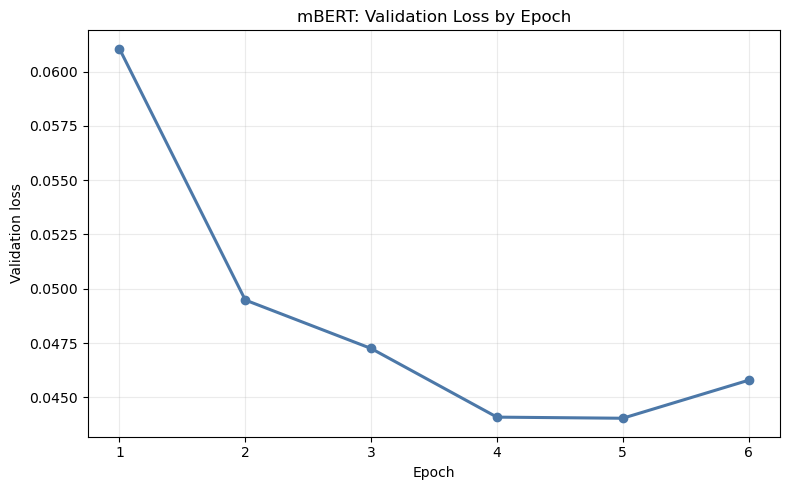

In [32]:
plot_epoch_metric("mBERT", "eval_loss", "Validation loss", "mBERT: Validation Loss by Epoch")


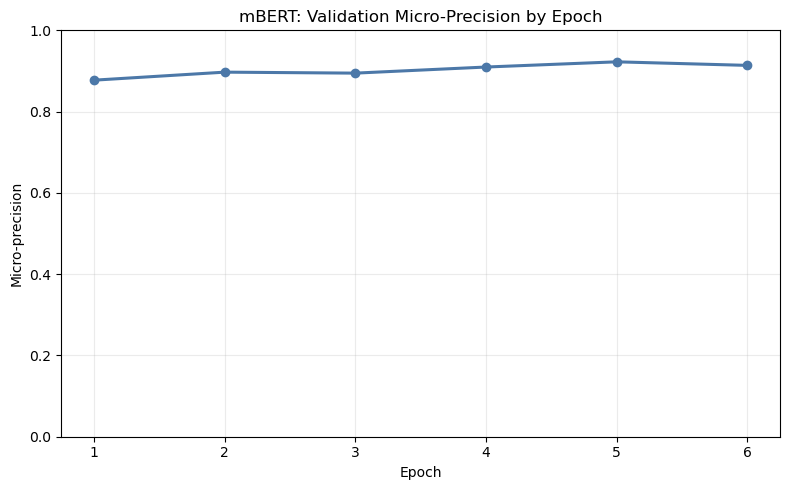

In [33]:
plot_epoch_metric("mBERT", "eval_micro_precision", "Micro-precision", "mBERT: Validation Micro-Precision by Epoch")


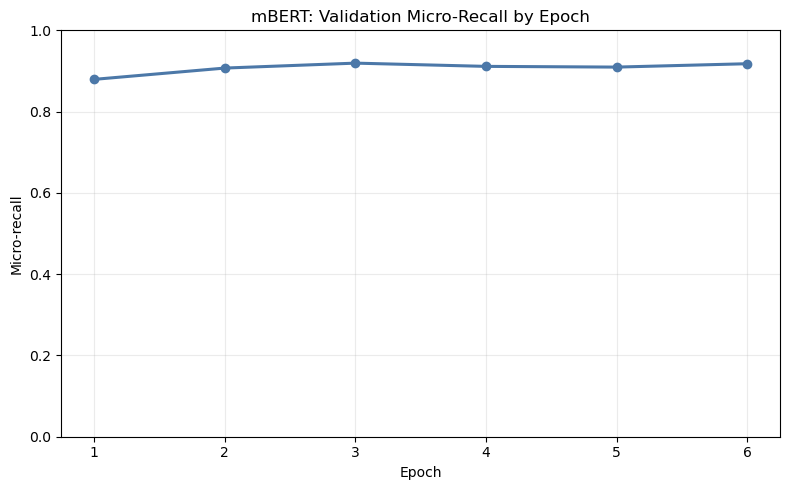

In [34]:
plot_epoch_metric("mBERT", "eval_micro_recall", "Micro-recall", "mBERT: Validation Micro-Recall by Epoch")


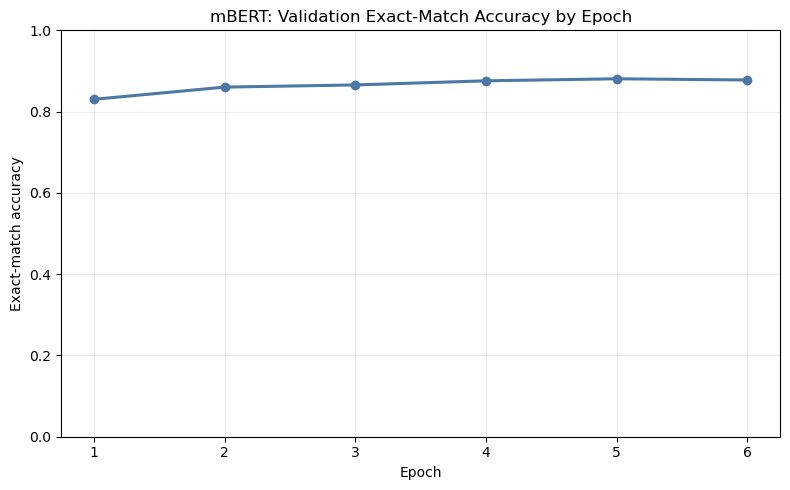

In [35]:
plot_epoch_metric("mBERT", "eval_exact_match_accuracy", "Exact-match accuracy", "mBERT: Validation Exact-Match Accuracy by Epoch")


### XLM-R validation curves


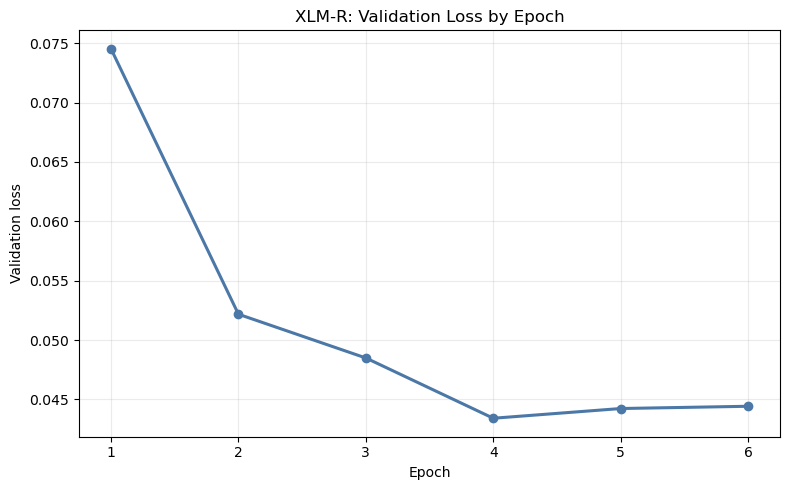

In [36]:
plot_epoch_metric("XLM-R", "eval_loss", "Validation loss", "XLM-R: Validation Loss by Epoch")


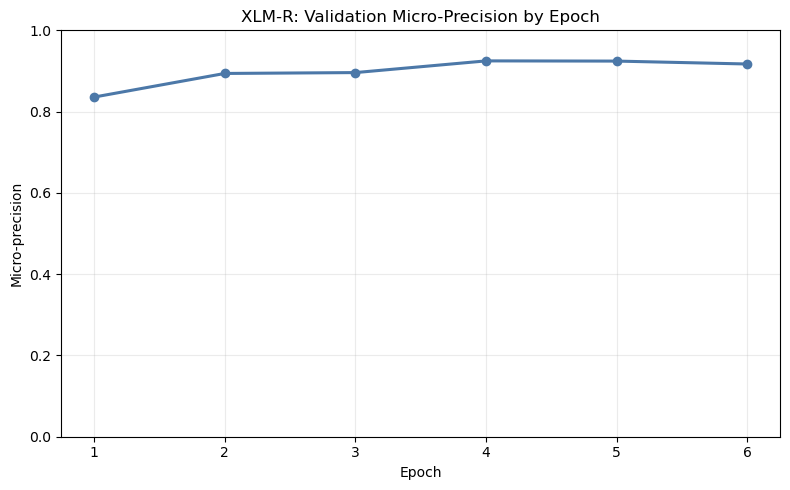

In [37]:
plot_epoch_metric("XLM-R", "eval_micro_precision", "Micro-precision", "XLM-R: Validation Micro-Precision by Epoch")


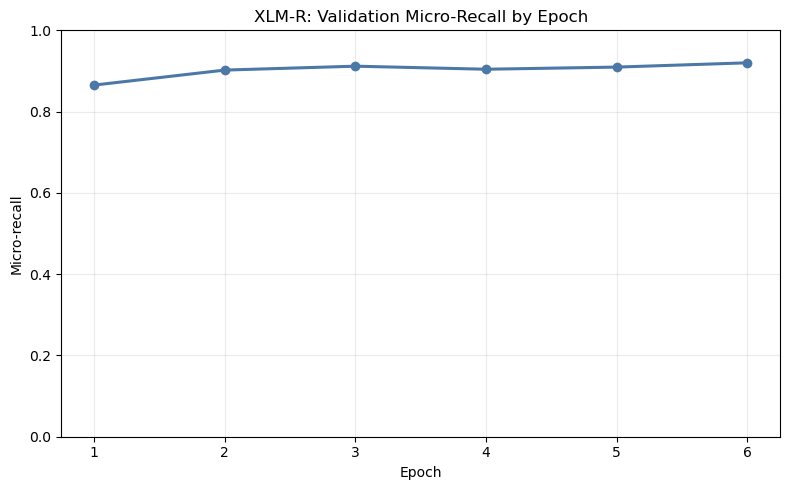

In [38]:
plot_epoch_metric("XLM-R", "eval_micro_recall", "Micro-recall", "XLM-R: Validation Micro-Recall by Epoch")


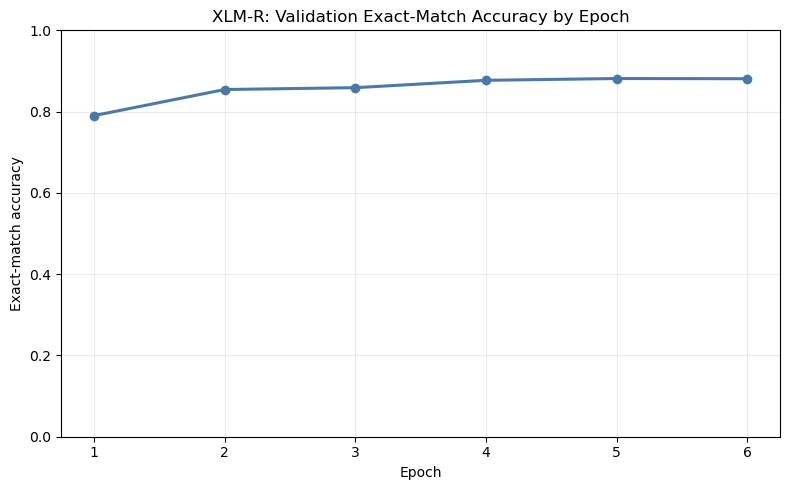

In [39]:
plot_epoch_metric("XLM-R", "eval_exact_match_accuracy", "Exact-match accuracy", "XLM-R: Validation Exact-Match Accuracy by Epoch")


### 4.3 TF-IDF + Linear SVM


In [40]:
clear_model_results("TFIDF-SVM")

tfidf = TfidfVectorizer(
    analyzer="char_wb", ngram_range=(3, 5), min_df=3,
    max_features=150_000, sublinear_tf=True, dtype=np.float32,
)
X_train = tfidf.fit_transform(train_df["text"])
X_val = tfidf.transform(val_df["text"])
X_test = tfidf.transform(test_df["text"])
y_train = np.asarray(train_df["labels"].tolist(), dtype=int)
y_val = np.asarray(val_df["labels"].tolist(), dtype=int)
y_test = np.asarray(test_df["labels"].tolist(), dtype=int)

for seed in SEEDS:
    print(f"\n{'=' * 12} TF-IDF + Linear SVM, seed={seed} {'=' * 12}")
    svm = OneVsRestClassifier(
        LinearSVC(class_weight="balanced", random_state=seed), n_jobs=-1
    )
    svm.fit(X_train, y_train)
    val_scores = svm.decision_function(X_val)
    test_scores = svm.decision_function(X_test)
    svm_threshold_grid = np.unique(
        np.quantile(val_scores.ravel(), np.linspace(0.01, 0.99, 199))
    )
    selected_threshold, threshold_curve = tune_global_threshold(
        y_val, val_scores, svm_threshold_grid,
        objective=GLOBAL_THRESHOLD_OBJECTIVE, default_threshold=DEFAULT_SVM_THRESHOLD
    )
    val_predictions, val_row = evaluate_fixed(y_val, val_scores, selected_threshold)
    test_predictions, row = evaluate_fixed(
        y_test, test_scores, selected_threshold
    )
    print("Global SVM threshold selected on validation only:", selected_threshold)
    run_id = f"TFIDF-SVM_seed{seed}_fixed"
    runs[run_id] = {
        "model": "TFIDF-SVM", "seed": seed,
        "estimator": svm, "predictions": test_predictions,
        "scores": test_scores, "y_true": y_test,
        "dataframe_order_aligned": True,
        "validation_metrics": val_row,
        "global_threshold": selected_threshold,
        "threshold_curve": threshold_curve,
    }
    comparison_rows.append({"split": "test", "model": "TFIDF-SVM", "seed": seed, **row})
    validation_rows.append({"split": "validation", "model": "TFIDF-SVM", "seed": seed, **val_row})

svm_results = pd.DataFrame([row for row in comparison_rows if row["model"] == "TFIDF-SVM"])
display(svm_results.sort_values(["seed"]))



============ TF-IDF + Linear SVM, seed=42 ============
Global SVM threshold selected on validation only: -0.05625430336200286


,split,model,seed,micro_f1,macro_f1,micro_precision,micro_recall,exact_match_accuracy,no_allergen_accuracy
0,test,TFIDF-SVM,42,0.853011,0.7604,0.811994,0.898393,0.790469,0.89922


### Summary


In [41]:
if not comparison_rows or not validation_rows:
    raise RuntimeError("Run the required model cells before creating the summary.")

metric_columns = [
    "micro_f1", "macro_f1", "micro_precision", "micro_recall",
    "exact_match_accuracy", "no_allergen_accuracy",
]
validation_comparison = pd.DataFrame(validation_rows).sort_values("model").reset_index(drop=True)
test_comparison = pd.DataFrame(comparison_rows).sort_values("model").reset_index(drop=True)

summary_table = pd.concat([
    validation_comparison[["split", "model", "seed", *metric_columns]],
    test_comparison[["split", "model", "seed", *metric_columns]],
], ignore_index=True).sort_values(["model", "split"])

display(summary_table)

best_overall_model_name = (
    validation_comparison.sort_values("macro_f1", ascending=False).iloc[0]["model"]
)
transformer_validation = validation_comparison[validation_comparison["model"].isin(MODEL_SPECS)]
best_model_name = transformer_validation.sort_values("macro_f1", ascending=False).iloc[0]["model"]
print("Best overall model using validation Macro-F1:", best_overall_model_name)
print("Transformer selected for fine-tuning:", best_model_name)

comparison = test_comparison.copy()
summary_table.to_csv(OUTPUT_ROOT / "validation_and_test_summary.csv", index=False)


,split,model,seed,micro_f1,macro_f1,micro_precision,micro_recall,exact_match_accuracy,no_allergen_accuracy
3,test,TFIDF-SVM,42,0.853011,0.760400,0.811994,0.898393,0.790469,0.899220
0,validation,TFIDF-SVM,42,0.847628,0.756214,0.797044,0.905066,0.787500,0.895274
4,test,XLM-R,42,0.915935,0.789745,0.918623,0.913262,0.880625,0.937407
1,validation,XLM-R,42,0.917874,0.802157,0.914091,0.921688,0.878906,0.936416
5,test,mBERT,42,0.915336,0.815734,0.918875,0.911823,0.880000,0.935248
2,validation,mBERT,42,0.914663,0.817330,0.911182,0.918172,0.876406,0.928936


Best overall model using validation Macro-F1: mBERT
Transformer selected for fine-tuning: mBERT


### 4.5 Final model comparison

This figure reports held-out test results. Model selection for fine-tuning is based on validation Macro-F1, not on this test figure.


In [42]:
print("comparison_rows" in globals())

if "comparison_rows" in globals():
    print(len(comparison_rows))
    print(comparison_rows)

True
3
[{'split': 'test', 'model': 'mBERT', 'seed': 42, 'micro_f1': 0.9153358478452772, 'macro_f1': 0.8157342086749916, 'micro_precision': 0.918875372593249, 'micro_recall': 0.9118234870892957, 'exact_match_accuracy': 0.88, 'no_allergen_accuracy': 0.9352482151751619}, {'split': 'test', 'model': 'XLM-R', 'seed': 42, 'micro_f1': 0.9159350571256765, 'macro_f1': 0.7897453615921485, 'micro_precision': 0.9186233515599871, 'micro_recall': 0.9132624510352546, 'exact_match_accuracy': 0.880625, 'no_allergen_accuracy': 0.9374066080026565}, {'split': 'test', 'model': 'TFIDF-SVM', 'seed': 42, 'micro_f1': 0.8530114994876465, 'macro_f1': 0.760400011931896, 'micro_precision': 0.8119942196531792, 'micro_recall': 0.8983931569270126, 'exact_match_accuracy': 0.79046875, 'no_allergen_accuracy': 0.8992196579777519}]


In [43]:
test_comparison = pd.DataFrame(comparison_rows)

display(test_comparison)

,split,model,seed,micro_f1,macro_f1,micro_precision,micro_recall,exact_match_accuracy,no_allergen_accuracy
0,test,mBERT,42,0.915336,0.815734,0.918875,0.911823,0.880000,0.935248
1,test,XLM-R,42,0.915935,0.789745,0.918623,0.913262,0.880625,0.937407
2,test,TFIDF-SVM,42,0.853011,0.760400,0.811994,0.898393,0.790469,0.899220


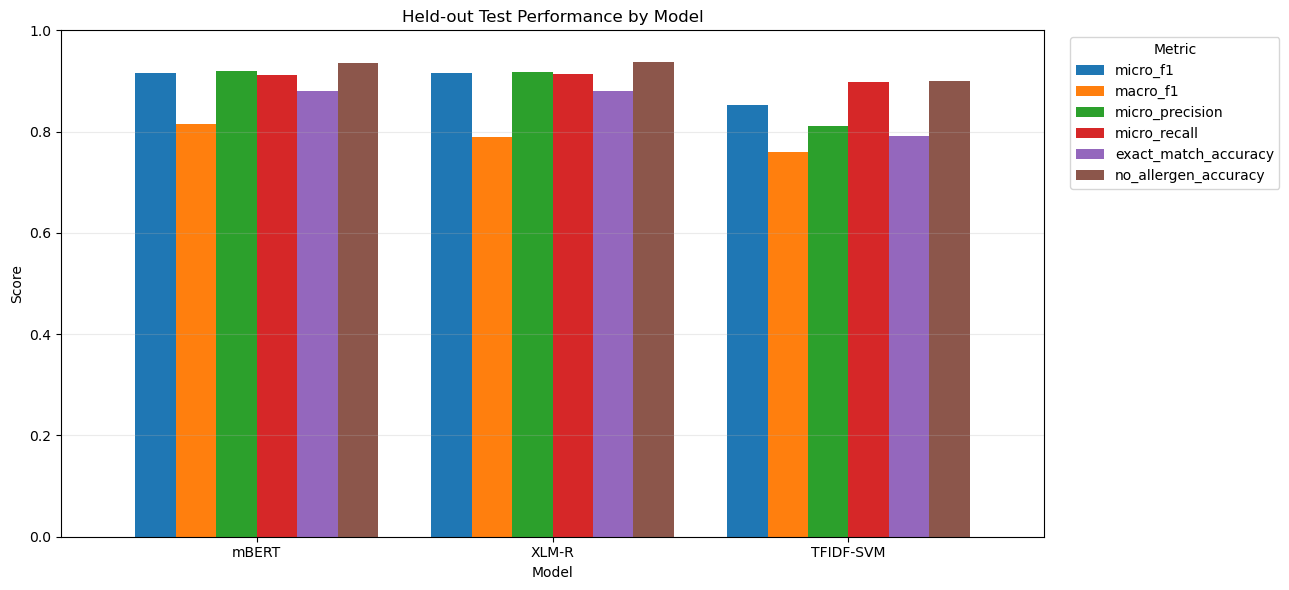

In [44]:
comparison_metrics = [
    "micro_f1", "macro_f1", "micro_precision", "micro_recall",
    "exact_match_accuracy", "no_allergen_accuracy"
]
plot_data = test_comparison.set_index("model")[comparison_metrics]

ax = plot_data.plot(kind="bar", figsize=(13, 6), width=0.82)
ax.set_title("Held-out Test Performance by Model")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## By language and allergen categories

Report each F1-score


In [45]:
language_rows, label_rows = [], []
for run_id, run in runs.items():
    model_name = run["model"]
    seed = run["seed"]
    y_pred = run["predictions"]
    y_true = run["y_true"]
    if not run.get("dataframe_order_aligned", False):
        print(f"Skipping by-language analysis for {run_id}: prediction order differs from test_df.")
        language_enabled = False
    else:
        language_enabled = True
    for lang in (sorted(test_df["lang"].unique()) if language_enabled else []):
        mask = test_df["lang"].to_numpy() == lang
        if mask.sum() >= 20:
            language_rows.append({
                "model": model_name, "seed": seed,
                "lang": lang, "n_samples": int(mask.sum()),
                "micro_f1": f1_score(y_true[mask], y_pred[mask], average="micro", zero_division=0),
                "macro_f1": f1_score(y_true[mask], y_pred[mask], average="macro", zero_division=0),
            })
    for i, label in enumerate(mlb.classes_):
        label_rows.append({
            "model": model_name, "seed": seed,
            "label": label, "support": int(y_true[:, i].sum()),
            "f1": f1_score(y_true[:, i], y_pred[:, i], zero_division=0),
        })

by_language = pd.DataFrame(language_rows).sort_values(["lang", "model"])
by_label = pd.DataFrame(label_rows).sort_values(["label", "model"])
language_summary = by_language.pivot(index="lang", columns="model", values=["micro_f1", "macro_f1"])
label_summary = by_label.pivot(index="label", columns="model", values="f1")
display(language_summary)
display(label_summary)
by_language.to_csv(OUTPUT_ROOT / "language_test_comparison.csv", index=False)
by_label.to_csv(OUTPUT_ROOT / "label_test_comparison.csv", index=False)
language_summary.to_csv(OUTPUT_ROOT / "language_test_comparison_pivot.csv")
label_summary.to_csv(OUTPUT_ROOT / "label_test_comparison_pivot.csv")


micro_f1                      macro_f1                    
model TFIDF-SVM     XLM-R     mBERT TFIDF-SVM     XLM-R     mBERT
lang                                                             
de     0.845151  0.913712  0.909030  0.732228  0.744122  0.775327
en     0.894509  0.926451  0.929463  0.742427  0.846263  0.831037
es     0.824573  0.892508  0.896352  0.701119  0.764915  0.777444
fr     0.849504  0.918851  0.924540  0.726217  0.765626  0.819042
it     0.832153  0.911890  0.910168  0.748288  0.785172  0.810864
nl     0.857665  0.909779  0.913480  0.794504  0.789503  0.818524
pl     0.849191  0.927163  0.916095  0.680903  0.780587  0.715330
pt     0.872818  0.922570  0.921659  0.797976  0.774779  0.843938

model,TFIDF-SVM,XLM-R,mBERT
label,,,
en:celery,0.816420,0.897959,0.905806
en:crustaceans,0.643836,0.534247,0.630872
en:eggs,0.806675,0.919767,0.912691
en:fish,0.828829,0.858612,0.864652
en:gluten,0.902308,0.934649,0.933152
en:lupin,0.573770,0.184615,0.476190
en:milk,0.907776,0.946494,0.947620
en:molluscs,0.622222,0.556701,0.577320
en:mustard,0.777132,0.897550,0.881432


## Example

The model output is the probability of each label independently; the threshold should be tuned on the validation set first, and should not be selected based on the test set.


In [46]:
def predict_allergens(text, model_name, seed=42):
    run = runs[f"{model_name}_seed{seed}_fixed"]
    if model_name == "TFIDF-SVM":
        raise ValueError("此推理函数用于 Transformer；SVM 需使用已拟合的 tfidf 和 estimator。")

    tokenizer = AutoTokenizer.from_pretrained(run["model_dir"])
    model = AutoModelForSequenceClassification.from_pretrained(run["model_dir"])
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device).eval()
    encoded = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH)
    encoded = {key: value.to(device) for key, value in encoded.items()}
    with torch.no_grad():
        probabilities = torch.sigmoid(model(**encoded).logits)[0].cpu().numpy()
    result = {
        label: round(float(probability), 3)
        for label, probability in zip(mlb.classes_, probabilities)
        if probability >= run["global_threshold"]
    }
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result


example = "Farine de blé, oeufs, lait, sucre"
for model_name in MODEL_SPECS:
    run_key = f"{model_name}_seed42_fixed"
    if run_key in runs:
        print(model_name, "->", predict_allergens(example, model_name, seed=42))


Loading weights: 100%|█████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 3025.93it/s]


mBERT -> {'en:gluten': 0.993, 'en:eggs': 0.994, 'en:milk': 0.988}


Loading weights: 100%|█████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 3223.49it/s]


XLM-R -> {'en:gluten': 0.993, 'en:eggs': 0.993, 'en:milk': 0.982}


In [47]:
def predict_allergens(text, model_name, seed=42):
    run = runs[f"{model_name}_seed{seed}_fixed"]

    if model_name == "TFIDF-SVM":
        raise ValueError(
            "此推理函数用于 Transformer；SVM 需使用已拟合的 tfidf 和 estimator。"
        )

    tokenizer = AutoTokenizer.from_pretrained(run["model_dir"])
    model = AutoModelForSequenceClassification.from_pretrained(run["model_dir"])

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device).eval()

    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    )
    encoded = {key: value.to(device) for key, value in encoded.items()}

    with torch.no_grad():
        probabilities = torch.sigmoid(
            model(**encoded).logits
        )[0].cpu().numpy()

    # 只返回超过 threshold 的 allergen 名称
    predicted_allergens = [
        label
        for label, probability in zip(mlb.classes_, probabilities)
        if probability >= run["global_threshold"]
    ]

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return predicted_allergens

In [48]:
def predict_allergens_svm(text, seed=42, show_scores=True):
    run = runs[f"TFIDF-SVM_seed{seed}_fixed"]

    estimator = run["estimator"]
    threshold = run["global_threshold"]

    # 使用已经训练好的 TF-IDF vectorizer
    X = tfidf.transform([text])

    # LinearSVC 输出 decision scores，不是真正 probability
    scores = estimator.decision_function(X)[0]

    predicted_allergens = [
        label
        for label, score in zip(mlb.classes_, scores)
        if score >= threshold
    ]

    if show_scores:
        result = {
            label: round(float(score), 3)
            for label, score in zip(mlb.classes_, scores)
            if score >= threshold
        }

        return {
            "global_threshold": round(float(threshold), 3),
            "predicted_allergens": predicted_allergens,
            "scores": result
        }

    return predicted_allergens

In [49]:
example = "Farine de blé, oeufs, lait, sucre"

result = predict_allergens_svm(example)
print(result)

{'global_threshold': -0.056, 'predicted_allergens': ['en:gluten', 'en:eggs', 'en:milk'], 'scores': {'en:gluten': 2.134, 'en:eggs': 2.688, 'en:milk': 0.799}}


### 7.1 Final test evaluation

Run the following cell only once after the fine-tuning configuration has been selected from validation results. Repeatedly consulting this test result to change parameters would cause test-set leakage.


In [34]:
best_trial = fine_tuning_results.iloc[0]
best_model_dir = best_trial["model_dir"]
best_max_length = int(best_trial["max_length"])
best_global_threshold = float(best_trial["global_threshold"])

final_tokenizer = AutoTokenizer.from_pretrained(best_model_dir)
final_model = AutoModelForSequenceClassification.from_pretrained(best_model_dir)

def final_tokenise(batch):
    return final_tokenizer(batch["text"], truncation=True, max_length=best_max_length)

final_test_dataset = Dataset.from_pandas(test_df, preserve_index=False)
columns_to_remove = [column for column in final_test_dataset.column_names if column != "labels"]
final_test_dataset = final_test_dataset.map(
    final_tokenise, batched=True, remove_columns=columns_to_remove
)

final_args = TrainingArguments(
    output_dir=str(OUTPUT_ROOT / "fine_tuning" / "final_test"),
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    report_to="none",
)
final_trainer = Trainer(
    model=final_model,
    args=final_args,
    processing_class=final_tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=final_tokenizer),
    compute_metrics=compute_metrics,
)
final_test_output = final_trainer.predict(final_test_dataset)
final_test_probabilities = 1 / (1 + np.exp(-final_test_output.predictions))
final_test_y = np.asarray(final_test_output.label_ids, dtype=int)
final_test_predictions, final_test_metrics = evaluate_fixed(
    final_test_y, final_test_probabilities, best_global_threshold
)
final_test_metrics["global_threshold"] = best_global_threshold
display(pd.Series(final_test_metrics, name="best_fine_tuned_model_test_result"))


NameError: name 'fine_tuning_results' is not defined